# Tasks: 
- do initial EDA
- how many data jobs are there in the data set?
- how many work years are represented?
- which countries exists in this dataset?
- what type of company sizes are there
- ratio of remote work vs office
- average salaries per job role
- median salaries per job role
- seniority level and average salaries?
- remote work and average salaries?
- company location and average salaries?
- clean job titles
- do different visualizations 
- export visualizations
- export cleaned data

## Initial EDA 

In [ ]:
import pandas as pd 

df_salaries = pd.read_csv("salaries.csv")

df_salaries


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
16529,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
16530,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
16531,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
16532,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [127]:
df_salaries.info()

<class 'pandas.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   work_year           16534 non-null  int64  
 1   experience_level    16534 non-null  str    
 2   employment_type     16534 non-null  str    
 3   job_title           16534 non-null  str    
 4   salary              16534 non-null  int64  
 5   salary_currency     16534 non-null  str    
 6   salary_in_usd       16534 non-null  int64  
 7   employee_residence  16534 non-null  str    
 8   remote_ratio        16534 non-null  int64  
 9   company_location    16534 non-null  str    
 10  company_size        16534 non-null  str    
 11  Remote ratio        0 non-null      float64
dtypes: float64(1), int64(4), str(7)
memory usage: 1.5 MB


In [129]:
df_salaries.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size', 'Remote ratio'],
      dtype='str')

In [128]:
df_salaries.describe()

,work_year,salary,salary_in_usd,remote_ratio,Remote ratio
count,16534.000000,1.653400e+04,16534.000000,16534.000000,0.0
mean,2023.226866,1.637270e+05,149686.777973,32.003750,NaN
std,0.713558,3.402057e+05,68505.293156,46.245158,NaN
min,2020.000000,1.400000e+04,15000.000000,0.000000,NaN
25%,2023.000000,1.017630e+05,101125.000000,0.000000,NaN
50%,2023.000000,1.422000e+05,141300.000000,0.000000,NaN
75%,2024.000000,1.872000e+05,185900.000000,100.000000,NaN
max,2024.000000,3.040000e+07,800000.000000,100.000000,NaN


In [ ]:
#T stands for transpose: rows  <-> cols (switch places)
df_salaries.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,16534.0,2023.226866,0.713558,2020.0,2023.0,2023.0,2024.0,2024.0
salary,16534.0,163726.962683,340205.744183,14000.0,101763.0,142200.0,187200.0,30400000.0
salary_in_usd,16534.0,149686.777973,68505.293156,15000.0,101125.0,141300.0,185900.0,800000.0
remote_ratio,16534.0,32.003750,46.245158,0.0,0.0,0.0,100.0,100.0
Remote ratio,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [138]:
print(f"Rows: {df_salaries.shape[0]}, Cols: {df_salaries.shape[1]}")

Rows: 16534, Cols: 12


### What does a row represent? 
- an employee based on col: employee_resident

In [139]:
# how many data jobs are there in the data set?
df_jobs_count = pd.DataFrame({"Job with Data in the title": [df_salaries.job_title.str.contains('data', case=False).sum()]})
df_jobs_count

,Job with Data in the title
0,11322


### Explore different categorical columns 

- experience level 
- job title 
- eployment type 
- employment residence
- remote ratio 
- ...

In [140]:
df_salaries["experience_level"].value_counts()

experience_level
SE    10670
MI     4038
EN     1325
EX      501
Name: count, dtype: int64

<Axes: title={'center': 'Employees by experience level in data field'}, xlabel='experience_level', ylabel='Number of employees'>

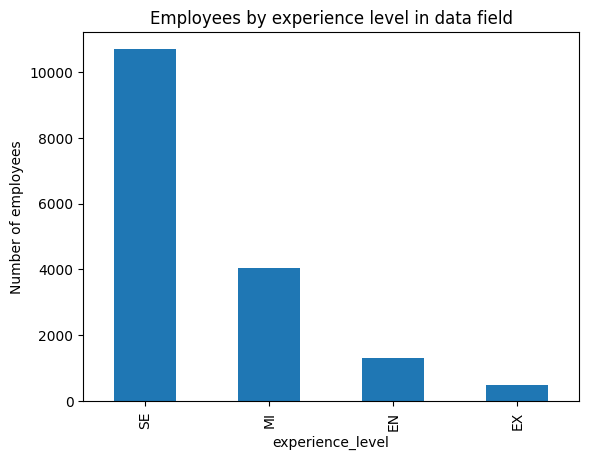

In [163]:
# .plot wrappes arount matplotlib and returns Axes instance 

ax = df_salaries["experience_level"].value_counts().plot(
    kind= "bar",
    ylabel="Number of employees", 
    title="Employees by experience level in data field"
    )

ax


In [167]:
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("employees_seniority_lvl.png", dpi=200)

In [141]:
df_salaries["job_title"].value_counts()

job_title
Data Engineer                3464
Data Scientist               3314
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
                             ... 
Deep Learning Researcher        1
Marketing Data Engineer         1
Data Science Tech Lead          1
Principal Data Architect        1
Cloud Data Architect            1
Name: count, Length: 155, dtype: int64

In [142]:
df_salaries["employment_type"].value_counts()

employment_type
FT    16454
PT       38
CT       28
FL       14
Name: count, dtype: int64

## Data Cleaning
- similare titles put togehter 
- ex Data scientist & data science


In [171]:
df_salaries["job_title"].value_counts().head(10)

job_title
Data Engineer                3464
Data Scientist               3314
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
Applied Scientist             435
Data Architect                435
Analytics Engineer            431
Research Engineer             306
Data Science                  271
Name: count, dtype: int64

In [ ]:
import duckdb 

duckdb.sql("""--sql 
    FROM df_salaries
    WHERE job_title ILIKE 'data scie%'

""").df()["job_title"].value_counts()

job_title
Data Scientist               3314
Data Science                  271
Data Science Manager          122
Data Science Consultant        83
Data Science Engineer          29
Data Science Lead              26
Data Science Practitioner      16
Data Science Director           8
Data Science Analyst            4
Data Scientist Lead             2
Data Science Tech Lead          1
Name: count, dtype: int64

In [ ]:
duckdb.sql("""--sql
           SELECT * EXCLUDE(job_title),
           CASE     
                WHEN job_title ILIKE 'data scie%'
           FROM df_salaries

           """).df()["job_title"].value_counts()



job_title
Data Engineer                3464
Data Scientist               3314
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
                             ... 
Deep Learning Researcher        1
Marketing Data Engineer         1
Data Science Tech Lead          1
Principal Data Architect        1
Cloud Data Architect            1
Name: count, Length: 155, dtype: int64

In [107]:
#how many work years are represented?

unique_work_years = pd.DataFrame(df_salaries.work_year.unique(), columns = ["Work years"])
unique_work_years

,Work years
0,2024
1,2022
2,2023
3,2020
4,2021


In [108]:
#which countries exists in this dataset?
df_countries = pd.DataFrame(df_salaries.company_location.unique(), columns = ["Country"])

df_countries

,Country
0,US
1,AU
2,GB
3,CA
4,NL
...,...
72,DZ
73,IQ
74,CN
75,CL


In [ ]:
#what type of company sizes are there

df_company_sizes = pd.DataFrame(df_salaries.company_size.unique(), columns=["Company size"])

df_company_sizes

,Company size
0,M
1,L
2,S


In [134]:
#ratio of remote work vs office

df_remote_ration = pd.DataFrame(df_salaries["remote_ratio"].map({0: "Onsite", 50: "Hybrid", 100: "Remote"}).value_counts())

df_remote_ration



,count
remote_ratio,
Onsite,11118
Remote,5167
Hybrid,249


In [ ]:
#average salaries per job role

job_titles = pd.DataFrame(df_salaries[["job_title", "salary"]])




print(job_titles)

TypeError: Cannot perform reduction 'mean' with string dtype